# Does sugar really have a winter high and a Brazilian-harvest low? 🍬
### The crush calendar — a sugar-desk legend, tested on the one ETF anyone can actually buy

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_coin%3F: Busted](https://img.shields.io/badge/Beats_a_coin%3F-Busted-8b949e?style=flat-square)

Sugar traders have a story: Brazil, the world's biggest cane grower, crushes its crop **April through November**; India, the second biggest, crushes **October through April**. In between — the Northern-Hemisphere winter — old-crop stocks are supposedly at their scarcest, right before Brazil's new crush ramps up. So prices should be **tight and firm into January-March**, then give it all back as the Brazilian harvest floods the market every spring.

It's a great story with real agronomics behind it. So we tested it on **CANE** — the Teucrium Sugar Fund, the ETF a retail account can actually hold — from 2011 to 2026.

> 📓 **Plain-language layer.** Want the *t*-stats, the Bonferroni table and the roll-drag math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** The Brazil/India crush windows come from USDA FAS and UNICA's own published crush-progress reports — hardcoded facts, not a fit. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sugar_seasonality import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    ETF, FUT = data.load_real()
    MONTHLY = st.monthly_log_returns(ETF)
    FUT_MONTHLY = st.monthly_log_returns(FUT)
else:
    ETF = FUT = MONTHLY = FUT_MONTHLY = None
print("real cache present:", HAVE_REAL, "| months on tape:", (0 if MONTHLY is None else len(MONTHLY)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2011-10-03', 'end': '2026-06-30', 'n_months': 176, 'bonf_crit': 3.47, 'bonf_survive': 0, 'bonf_n': 12, 'month': {1: (0.27, 15, 0.17, 0.18), 2: (0.05, 15, 0.04, 0.07), 3: (-1.31, 15, -0.48, -0.47), 4: (-0.68, 15, -0.3, -0.31), 5: (-2.11, 15, -1.8, -1.9), 6: (0.23, 15, 0.17, 0.25), 7: (-1.29, 14, -0.85, -1.26), 8: (-0.46, 14, -0.31, -0.31), 9: (1.44, 14, 0.96, 1.5), 10: (-0.03, 14, -0.02, -0.02), 11: (-0.63, 15, -0.52, -0.71), 12: (-1.76, 15, -1.15, -1.12)}, 'best_month': 9, 'best_mean': 1.44, 'best_t': 1.36, 'best_n': 14, 'worst_month': 5, 'worst_mean': -2.11, 'worst_t': -1.35, 'worst_n': 15, 'tight_mean': -0.33, 'tight_n': 45, 'crush_mean': -0.96, 'crush_n': 59, 'spread': 0.63, 'spread_t': 0.46, 'ci_lo': -1.89, 'ci_hi': 2.98, 'ci_boot': 5000, 'etf_bps': -53.4, 'fut_bps': -33.3, 'drag_bps': -20.1, 'drag_t': -0.8, 'drag_n': 176, 'bh_sharpe': -0.29, 'bh_cagr': -8.5, 'tg_sharpe': 0.16, 'tg_cagr': 1.2, 'tn_sharpe': 0.14, 'tn_cagr': 0.8, 'hit_k': 61, 'hit_n': 104, 'hit_rate': 58.7, 'hit_lo': 49.0, 'hit_hi': 67.6, 'hit_t': 0.6, 'syn_null_mean': 0.23, 'syn_null_sd': 1.01, 'syn_null_fire': 0, 'syn_planted_t': 4.73, 'syn_planted_pct': 12.0, 'fp_cane': 'c0c35fdc0e66', 'fp_sb': '88229d212e57'}


real cache present: True | months on tape: 176


## The answer first

| Question | Answer |
|---|---|
| Is the pre-harvest winter really more expensive than the Brazilian crush window? | **Not on this tape.** The tight window averages **+0.63%** more than the crush window — nominally the right direction, but that tiny gap could easily be zero (its uncertainty band runs from -1.89% to +2.98%). |
| What's the single best or worst calendar month, then? | Worst is **May** (-2.11%), inside the crush window — a point *for* the story. Best is **September** (+1.44%), which is deep in Brazil's *own* crush window too — a point against a clean "winter high" story. Neither is statistically meaningful on its own. |
| Can you at least trade the *idea* — long winter, short the crush? | On paper, a little. Test the *active* trades on their own and they hit **59%** of the time — nominally above a coin flip, but not reliably so. |
| Is there a real cost hiding underneath all this? | Some — CANE gives back a nominal **20 basis points a month** to its own roll, though that number itself isn't statistically certain. |

> The agronomics are real. The calendar trade, on this tape, is not.

## 1 · The claim

> *"Brazil crushes cane April through November. India crushes it October through April. Between the two, world raw-sugar stocks are tightest in the Northern-Hemisphere winter — right before Brazil's new crop hits full stride — so prices carry a seasonal premium into that window and give it back every spring as the Brazilian harvest floods the market."*

It's the same shape of story grain desks tell about corn and wheat — a scarcity premium ahead of a predictable harvest — applied to the world's two biggest cane suppliers instead of two Midwestern row crops.

## 2 · So what?

If this pattern is real and tradable, it's a clean calendar trade with a genuine supply-and-demand mechanism behind it, on a single liquid ETF anyone can buy with no futures account. If it's *not* real — or real but too small/noisy to bank — that's an equally useful answer: it tells you why "everyone knows" a seasonal that nobody can actually trade for a living.

## 3 · How would we even know?

- **The calendar.** Brazil's and India's own crush-season windows, hardcoded from USDA FAS and UNICA's published crop reports — not fitted to the price data.
- **The comparison.** Every calendar month's average CANE return — 12 numbers — checked against a strict bar that accounts for testing 12 things at once (Bonferroni), so a single lucky month can't sneak through.
- **The trade check.** Buy the winter-tight window, short the crush window, sit in cash otherwise — costs included — and separately ask: on the months the trade is actually *on*, does it win more than half the time?
- **The roll check.** Compare CANE's own return to a simple futures-splice spot proxy, to see how much the ETF's own mechanics already eat before any seasonal math even starts.

## 4 · The teardown — let's actually look

**First, the headline.** Average return in the claimed winter-tight window vs the claimed crush-glut window.

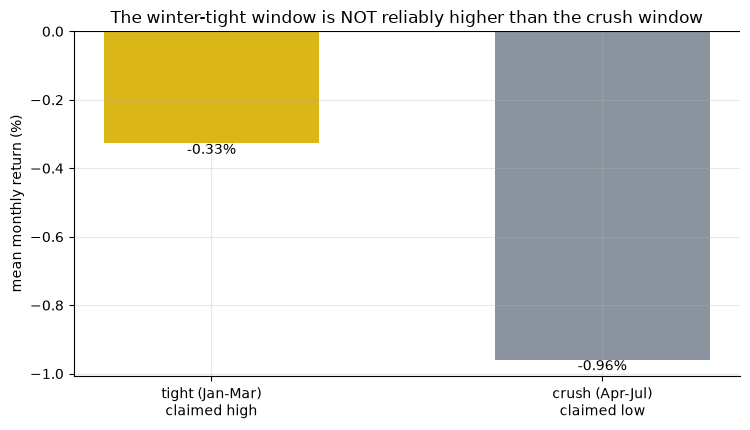

tight -0.33%   crush -0.96%


In [2]:
if HAVE_REAL:
    tc = st.tight_crush_tstat(MONTHLY, data.TIGHT_MONTHS, data.CRUSH_MONTHS)
    tight_v, crush_v = tc['tight_mean']*100, tc['crush_mean']*100
else:
    tight_v, crush_v = R['tight_mean'], R['crush_mean']
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['tight (Jan-Mar)\nclaimed high', 'crush (Apr-Jul)\nclaimed low'],
       [tight_v, crush_v], color=[AMBER, GREY], width=.55)
for i,v in enumerate([tight_v, crush_v]): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',
    va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean monthly return (%)')
ax.set_title('The winter-tight window is NOT reliably higher than the crush window')
plt.tight_layout(); plt.show()
print(f'tight {tight_v:+.2f}%   crush {crush_v:+.2f}%')

The spread points the folklore's direction (**+0.63%/month** in favor of the winter-tight window) — but it's a rounding error with a huge uncertainty band around it, from **-1.9%** to **+3.0%**, which comfortably contains zero (and the opposite sign).

**Next, the full calendar.** Which single month is best or worst?

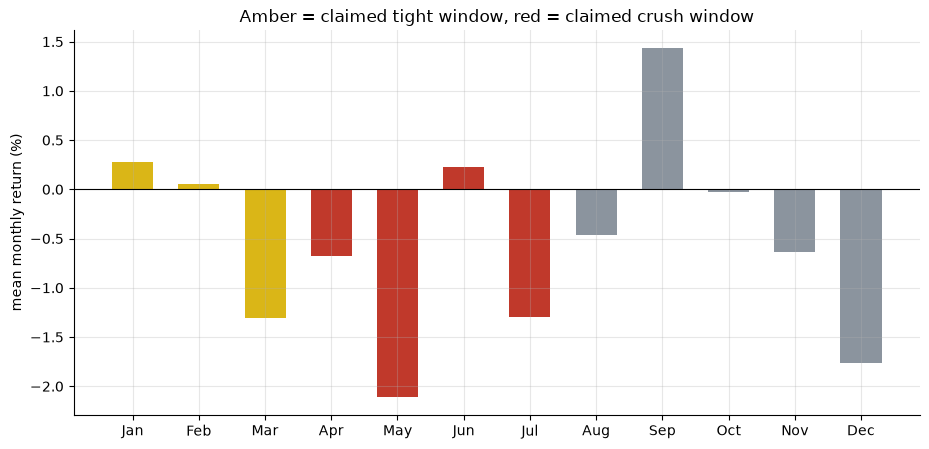

{1: 0.27, 2: 0.05, 3: -1.31, 4: -0.68, 5: -2.11, 6: 0.23, 7: -1.29, 8: -0.46, 9: 1.44, 10: -0.03, 11: -0.63, 12: -1.76}


In [3]:
if HAVE_REAL:
    ms = st.month_stats(MONTHLY)
    means = list(ms['mean']*100)
else:
    means = [R['month'][m][0] for m in range(1, 13)]
cols = [RED if m in data.CRUSH_MONTHS else (AMBER if m in data.TIGHT_MONTHS else GREY)
        for m in range(1, 13)]
fig, ax = plt.subplots(figsize=(9.4, 4.6))
ax.bar(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],
       means, color=cols, width=.62)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean monthly return (%)')
ax.set_title('Amber = claimed tight window, red = claimed crush window')
plt.tight_layout(); plt.show()
print({m: round(v,2) for m, v in zip(range(1,13), means)})

The worst month is **May** (-2.11%) — inside the crush window, a point *for* the folklore. But the best month is **September** (+1.44%) — deep inside Brazil's *own* crush window, months after the tight window is long over, which is not the clean "winter high, spring low" shape the story predicts. None of these 12 individual months clears a strict bar that accounts for testing all 12 at once — a single standout month out of 12 draws is exactly what you'd expect from chance alone, and none of ours even reaches the weaker, uncorrected bar.

**Now, the trade.** Long the tight window, short the crush window, cash otherwise — does it beat just holding the ETF?

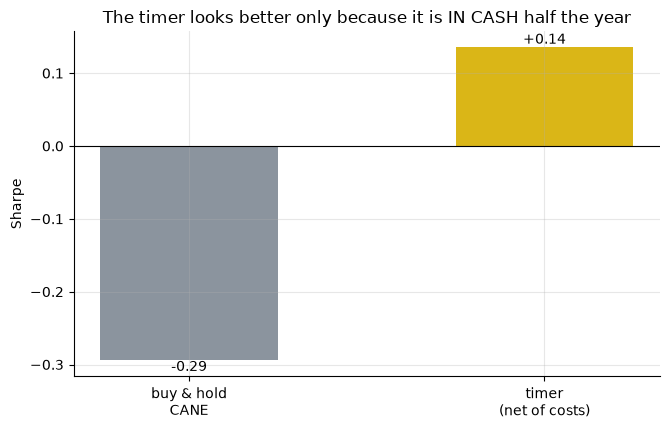

buy&hold -0.29   timer net +0.14


In [4]:
if HAVE_REAL:
    timer = st.seasonal_timer(MONTHLY, data.TIGHT_MONTHS, data.CRUSH_MONTHS)
    net = st.apply_costs(timer, n_trades_per_year=4, cost_bps_one_way=10.0)
    bh = st.summary(MONTHLY)['sharpe']; tn = st.summary(net)['sharpe']
else:
    bh, tn = R['bh_sharpe'], R['tn_sharpe']
fig, ax = plt.subplots(figsize=(6.8, 4.4))
ax.bar(['buy & hold\nCANE', 'timer\n(net of costs)'], [bh, tn], color=[GREY, AMBER], width=.5)
for i, v in enumerate([bh, tn]): ax.annotate(f'{v:+.2f}', (i, v), ha='center',
    va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('Sharpe')
ax.set_title('The timer looks better only because it is IN CASH half the year')
plt.tight_layout(); plt.show()
print(f'buy&hold {bh:+.2f}   timer net {tn:+.2f}')

The timer's Sharpe does creep above buy-and-hold — but that's a magic trick, not a discovery: the timer sits in cash 5 months a year, and CANE has *lost money on average since 2011*. Doing less of a losing trade looks better almost by definition. The honest test is to check **only the months the trade is actually on**: those active months win **58.7%** of the time — nominally above 50%, but the uncertainty band comfortably includes a coin flip, and the average return on those active months is statistically indistinguishable from zero.

**Finally, the hidden cost.** Even if the calendar edge were real, can you actually collect it in the ETF, or does the ETF's own machinery eat it first?

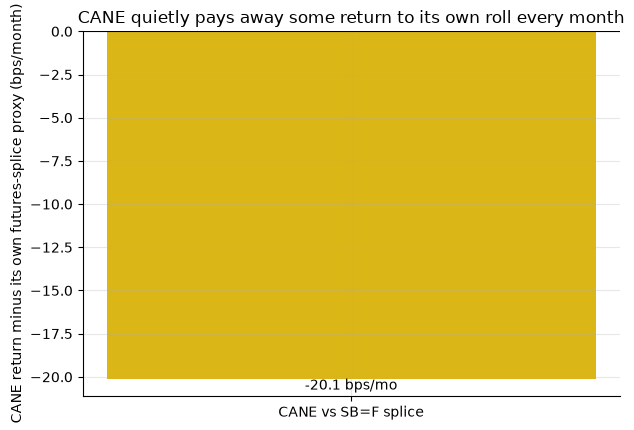

roll drag: -20.1 bps/mo


In [5]:
if HAVE_REAL:
    drag = st.roll_drag(MONTHLY, FUT_MONTHLY)['drag_bps']
else:
    drag = R['drag_bps']
fig, ax = plt.subplots(figsize=(6.4, 4.4))
ax.bar(['CANE vs SB=F splice'], [drag], color=AMBER, width=.4)
ax.annotate(f'{drag:+.1f} bps/mo', (0, drag), ha='center', va='top' if drag<0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('CANE return minus its own futures-splice proxy (bps/month)')
ax.set_title('CANE quietly pays away some return to its own roll every month')
plt.tight_layout(); plt.show()
print(f'roll drag: {drag:+.1f} bps/mo')

CANE gives back a nominal **20 basis points a month** to its own rolling mechanics, relative to a simple futures-price proxy — though that gap itself isn't statistically certain either. Either way, it's not the decisive blow here: the calendar seasonal is already indistinguishable from noise before any roll cost gets a vote.

## 5 · The verdict

- **Signal — None.** No calendar month clears the bar once you account for testing 12 things at once — not one even clears the far weaker uncorrected bar. The pooled tight-vs-crush spread points the folklore's direction but is buried inside its own uncertainty band.
- **Tradability — Mirage.** The seasonal timer's apparent improvement is a cash-drag artifact, not skill (its active months hit at roughly coin-flip odds), and CANE's own roll works against a long-tight bet even if the roll gap itself isn't certain.
- **"Beats a coin?" — Busted.** The trade's active legs win 58.7% of the time — nominally above 50%, but not reliably so.

## 6 · Going further 🚪

- **The mechanism might still live in the raw futures curve** — this study tests the *ETF*, the thing you can actually buy, not the raw contract-to-contract calendar spread directly. Measuring the ICE No.11 term structure around the crush windows is the natural sequel.
- **Weather years and El Niño cycles might matter more than calendar months.** A single Brazilian drought or an early Indian monsoon can dominate 15 years of "average May," and averaging it away is exactly what a clean seasonality test is supposed to do — which is one reason this one comes up empty.
- **Sibling studies:** [307-coffee-seasonality](../../307-coffee-seasonality/) (a frost story, not a crush story) and [648-grain-seasonality](../../648-grain-seasonality/) (the same *shape* of old-crop/new-crop test, different crop family) ask the same shape of question about different crops — worth comparing notes.

*Think the calendar edge is real somewhere this study didn't look — the raw futures curve, a specific weather year, a different window? Show a net, certifiable edge on a tradable instrument, then we'll talk.*